# Dynamic-NN v3 — MAS Sensitivity Signal Benchmark

**The Holy Grail of Structural Plasticity:**  
How does a neural network know when it needs to grow a new neuron? 

If it uses loss, it gets fooled by catastrophic forgetting (the loss spikes when returning to a forgotten familiar task, causing unnecessary growth). 

**The Solution:**  
Memory Aware Synapses (MAS) parameter sensitivity (Aljundi 2018). We measure how sensitive the network's output is to its weights. When novel data is encountered, it excites unstructured pathways and sensitivity spikes massively. When familiar data is encountered (even if forgotten), the underlying structural pathways remain flat, and sensitivity stays low.

**Sequence tested:** A → B → C → A  
- A = Circles (familiar on second visit)  
- B = Linear boundary (novel)  
- C = XOR (novel)  

**Self-contained:** This notebook runs entirely without any local files.

---

## Cell 1: Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## Cell 2: Dynamic Network

In [2]:
class PyTorchDynamicNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, max_neurons=500, steps=3):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.max_neurons = max_neurons
        self.steps = steps
        self.output_indices = list(range(input_dim, input_dim + output_dim))
        self.active_neurons = input_dim + output_dim + 4
        self.free_neurons = set()
        self.register_buffer('M', torch.zeros(max_neurons, max_neurons))
        self.register_buffer('trainable_mask', torch.ones(max_neurons, max_neurons))
        self.register_buffer('neuron_stress', torch.zeros(max_neurons))
        self.loss_ema = 0.0
        self.fast_loss_ema = 0.0
        self.slow_loss_ema = 0.0
        self.W = nn.Parameter(torch.zeros(max_neurons, max_neurons))
        self.b = nn.Parameter(torch.zeros(max_neurons))
        self._hook_registered = False
        self._init_random_connections()

    def _init_random_connections(self):
        with torch.no_grad():
            for i in range(self.active_neurons):
                for j in range(self.active_neurons):
                    if i != j and i >= self.input_dim:
                        if torch.rand(1).item() > 0.5:
                            self.M[i, j] = 1.0
            mask = self.M[:self.active_neurons, :self.active_neurons].bool()
            self.W[:self.active_neurons, :self.active_neurons][mask] = torch.randn(mask.sum()) * 0.1

    def _register_hooks(self):
        def _w_hook(grad): return grad * self.trainable_mask * self.M
        def _b_hook(grad):
            b_mask = torch.ones_like(grad)
            for i in range(self.active_neurons):
                if self.M[i,:].sum() > 0 and (self.M[i,:] * self.trainable_mask[i,:]).sum() == 0:
                    b_mask[i] = 0.0
            return grad * b_mask
        self.W.register_hook(_w_hook)
        self.b.register_hook(_b_hook)
        self._hook_registered = True

    def forward(self, x):
        if not self._hook_registered:
            self._register_hooks()
        batch = x.size(0)
        state = torch.zeros(batch, self.max_neurons, device=x.device)
        state[:, :self.input_dim] = x
        W_eff = self.W * self.M
        for _ in range(self.steps):
            new_state = torch.relu(torch.matmul(state, W_eff.T) + self.b)
            state = torch.cat([x, new_state[:, self.input_dim:]], dim=1)
        return state[:, self.output_indices]

    def update_stress(self, g_task, g_replay, beta=0.9):
        with torch.no_grad():
            conflict = torch.relu(-(g_task * g_replay))
            self.neuron_stress = beta * self.neuron_stress + (1-beta) * conflict.sum(dim=1)

    def update_loss_ema(self, loss, beta=0.9, fast_beta=0.5, slow_beta=0.99):
        self.loss_ema       = beta      * self.loss_ema       + (1-beta)      * loss
        self.fast_loss_ema  = fast_beta * self.fast_loss_ema  + (1-fast_beta) * loss
        self.slow_loss_ema  = slow_beta * self.slow_loss_ema  + (1-slow_beta) * loss

    def grow_neuron(self, num_connections=5):
        new_idx = self.free_neurons.pop() if self.free_neurons else None
        if new_idx is None:
            if self.active_neurons >= self.max_neurons: return -1
            new_idx = self.active_neurons
            self.active_neurons += 1
        with torch.no_grad():
            self.M[new_idx,:] = 0; self.M[:,new_idx] = 0
            self.trainable_mask[new_idx,:] = 1; self.trainable_mask[:,new_idx] = 1
            self.neuron_stress[new_idx] = 0
            valid_src = list(range(self.input_dim)) + [
                n for n in range(self.input_dim+self.output_dim, self.active_neurons)
                if n < self.active_neurons and n not in self.free_neurons and n != new_idx
            ]
            if valid_src:
                for s in torch.randperm(len(valid_src))[:min(num_connections, len(valid_src))]:
                    self.M[new_idx, valid_src[s.item()]] = 1.0
            valid_tgt = [
                n for n in range(self.input_dim, self.active_neurons)
                if n < self.active_neurons and n not in self.free_neurons and n != new_idx
            ]
            if valid_tgt:
                for t in torch.randperm(len(valid_tgt))[:min(num_connections, len(valid_tgt))]:
                    self.M[valid_tgt[t.item()], new_idx] = 1.0
            in_mask = self.M[new_idx,:].bool()
            self.W[new_idx, in_mask] = torch.randn(in_mask.sum()) * 0.1
            out_mask = self.M[:,new_idx].bool()
            self.W[out_mask, new_idx] = torch.randn(out_mask.sum()) * 0.1
            self.b[new_idx] = 0.0
        return new_idx

    def prune_dead_neurons(self, threshold=1e-3):
        n = 0
        with torch.no_grad():
            W_eff = self.W * self.M
            for idx in range(self.input_dim + self.output_dim, self.active_neurons):
                if idx in self.free_neurons: continue
                if torch.sum(torch.abs(W_eff[idx,:])).item() < threshold:
                    self.M[idx,:] = 0; self.M[:,idx] = 0
                    self.free_neurons.add(idx); n += 1
        return n

    def merge_redundant_neurons(self, similarity_threshold=0.95):
        n = 0
        with torch.no_grad():
            W_eff = self.W * self.M
            hiddens = [i for i in range(self.input_dim+self.output_dim, self.active_neurons)
                       if i not in self.free_neurons]
            for i in range(len(hiddens)):
                if hiddens[i] in self.free_neurons: continue
                vi = W_eff[hiddens[i],:]; ni = torch.norm(vi)
                if ni == 0: continue
                for j in range(i+1, len(hiddens)):
                    if hiddens[j] in self.free_neurons: continue
                    vj = W_eff[hiddens[j],:]; nj = torch.norm(vj)
                    if nj == 0: continue
                    if torch.dot(vi,vj)/(ni*nj) > similarity_threshold:
                        self.W[:,hiddens[i]] += self.W[:,hiddens[j]]
                        self.M[hiddens[j],:] = 0; self.M[:,hiddens[j]] = 0
                        self.free_neurons.add(hiddens[j]); n += 1
        return n

    def compress_network(self, prune_threshold=1e-3, similarity_threshold=0.95):
        return self.prune_dead_neurons(prune_threshold), self.merge_redundant_neurons(similarity_threshold)

print('PyTorchDynamicNetwork defined.')

PyTorchDynamicNetwork defined.


## Cell 3: MAS Sensitivity Signal

**One class. One metric. One threshold.**

Based on Memory Aware Synapses (Aljundi et al., 2018):  
Measures how sensitive the network's output is to its weights.  
Familiar inputs = low sensitivity (flat minima).  
Novel inputs = high sensitivity (unstructured pathways).

In [3]:
class MASSignal:
    def __init__(self, grow_margin=1.5, compress_margin=0.8,
                 fast_alpha=0.1, slow_alpha=0.01, burnin=30):
        self.grow_margin     = grow_margin
        self.compress_margin = compress_margin
        self.fast_alpha      = fast_alpha
        self.slow_alpha      = slow_alpha
        self.burnin          = burnin
        self.fast_ema        = None
        self.slow_ema        = None
        self.step            = 0

    def reset(self):
        self.fast_ema = None
        self.slow_ema = None
        self.step = 0

    def score(self, network, X):
        network.zero_grad()
        pred = network(X)[:, 0]
        out_mag = pred.pow(2).mean()
        grads = torch.autograd.grad(out_mag, network.W, retain_graph=True, allow_unused=True)[0]
        
        if grads is None:
            return {'mas': 0.0, 'decision': 'HOLD'}
            
        mas_val = torch.norm(grads).item()
        
        if self.fast_ema is None:
            self.fast_ema = mas_val
            self.slow_ema = mas_val
        else:
            self.fast_ema = (1 - self.fast_alpha) * self.fast_ema + self.fast_alpha * mas_val
            self.slow_ema = (1 - self.slow_alpha) * self.slow_ema + self.slow_alpha * mas_val
            
        self.step += 1
        
        if self.step < self.burnin:
            return {'mas': mas_val, 'decision': 'BURNIN'}
            
        if self.fast_ema > self.slow_ema * self.grow_margin:
            decision = 'GROW'
        elif self.fast_ema < self.slow_ema * self.compress_margin:
            decision = 'COMPRESS'
        else:
            decision = 'HOLD'
            
        return {'mas': mas_val, 'decision': decision}

print('MASSignal defined.')

MASSignal defined.


## Cell 4: Data Generators + Replay Buffer

In [4]:
def make_circles(n, seed=None):
    if seed is not None: np.random.seed(seed)
    theta = np.random.uniform(0, 2*np.pi, n)
    r = np.where(np.random.rand(n) > 0.5, 1.0, 0.5)
    x = r * np.cos(theta) + np.random.randn(n) * 0.05
    y = r * np.sin(theta) + np.random.randn(n) * 0.05
    return torch.FloatTensor(np.c_[x, y]), torch.FloatTensor((r == 1.0).astype(int)).unsqueeze(1)

def make_linear(n, seed=None):
    if seed is not None: np.random.seed(seed)
    x = np.random.uniform(-1.5, 1.5, n)
    y = np.random.uniform(-1.5, 1.5, n)
    X = np.c_[x + np.random.randn(n)*0.05, y + np.random.randn(n)*0.05]
    return torch.FloatTensor(X), torch.FloatTensor((x + y > 0).astype(int)).unsqueeze(1)

def make_xor(n, seed=None):
    if seed is not None: np.random.seed(seed)
    x = np.random.uniform(-1.5, 1.5, n)
    y = np.random.uniform(-1.5, 1.5, n)
    X = np.c_[x + np.random.randn(n)*0.05, y + np.random.randn(n)*0.05]
    return torch.FloatTensor(X), torch.FloatTensor(((x*y) > 0).astype(int)).unsqueeze(1)


class ReplayBuffer:
    def __init__(self, capacity=500):
        self.capacity = capacity
        self.X = self.y = None

    def add(self, X, y, n=16):
        idx = torch.randperm(X.size(0))[:n]
        Xs, ys = X[idx].clone(), y[idx].clone()
        if self.X is None:
            self.X, self.y = Xs, ys
        else:
            self.X = torch.cat([self.X, Xs])
            self.y = torch.cat([self.y, ys])
            if self.X.size(0) > self.capacity:
                keep = torch.randperm(self.X.size(0))[:self.capacity]
                self.X, self.y = self.X[keep], self.y[keep]

    def sample(self, n=64):
        if self.X is None: return None, None
        idx = torch.randint(0, self.X.size(0), (min(n, self.X.size(0)),))
        return self.X[idx], self.y[idx]

    def has_data(self): return self.X is not None

print('Data generators and ReplayBuffer defined.')

Data generators and ReplayBuffer defined.


## Cell 5: Training Loop

In [5]:
def run(seed, mode, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    n = 4000
    phases = [
        ('A1 (Circles)', *make_circles(n, seed=seed)),
        ('B  (Linear)',  *make_linear(n,  seed=seed+1)),
        ('C  (XOR)',     *make_xor(n,     seed=seed+2)),
        ('A2 (Circles)', *make_circles(n, seed=seed+3)),
    ]
    X_eval, y_eval = make_circles(500, seed=seed+99)

    stream_X = torch.cat([p[1] for p in phases])
    stream_y = torch.cat([p[2] for p in phases])

    batch_size  = 16
    phase_len   = n // batch_size
    boundaries  = [i * phase_len for i in range(len(phases))]

    net    = PyTorchDynamicNetwork(input_dim=2, output_dim=1, max_neurons=500)
    opt    = torch.optim.Adam(net.parameters(), lr=0.01, weight_decay=1e-4)
    crit   = nn.MSELoss()
    replay = ReplayBuffer(500)
    signal = MASSignal()

    fast_ema = slow_ema = 0.5  # for macd_baseline

    total       = 0
    since_grow  = 0
    phase_grows = [0, 0, 0, 0]
    mas_log   = []   # track mas score over time
    current_phase = 0

    for i in range(0, stream_X.size(0), batch_size):
        if total in boundaries:
            current_phase = boundaries.index(total)
            if verbose:
                print(f'  Phase {current_phase}: {phases[current_phase][0]}')

        bx = stream_X[i:i+batch_size]
        by = stream_y[i:i+batch_size]

        opt.zero_grad()
        pred = net(bx)[:, 0].unsqueeze(1)
        loss = crit(pred, by)

        if replay.has_data():
            rx, ry    = replay.sample(64)
            r_pred    = net(rx)[:, 0].unsqueeze(1)
            loss_r    = crit(r_pred, ry)
            g_t = torch.autograd.grad(loss,   net.W, retain_graph=True, allow_unused=True)[0]
            g_r = torch.autograd.grad(loss_r, net.W, retain_graph=True, allow_unused=True)[0]
            if g_t is not None and g_r is not None:
                net.update_stress(g_t, g_r)
            loss = loss + loss_r

        if mode == 'macd_baseline':
            loss.backward()
            opt.step()
            net.update_loss_ema(loss.item())

        should_grow = False
        if since_grow > 20:
            if mode == 'macd_baseline':
                fast_ema = 0.9  * fast_ema + 0.1  * loss.item()
                slow_ema = 0.99 * slow_ema + 0.01 * loss.item()
                if fast_ema > slow_ema * 1.15:
                    should_grow = True
            elif mode == 'mas_signal':
                result = signal.score(net, bx)
                mas_log.append((total, current_phase, result['mas']))
                
                # Recover gradients after score() zeroes them
                opt.zero_grad()
                pred = net(bx)[:, 0].unsqueeze(1)
                loss = crit(pred, by)
                if replay.has_data():
                    rx, ry = replay.sample(64)
                    loss += crit(net(rx)[:, 0].unsqueeze(1), ry)
                loss.backward()
                opt.step()
                
                if result['decision'] == 'GROW':
                    should_grow = True
                elif result['decision'] == 'COMPRESS' and total % 100 == 0:
                    net.compress_network(prune_threshold=0.15, similarity_threshold=0.50)

        if should_grow and net.active_neurons < net.max_neurons:
            net.grow_neuron(10)
            phase_grows[current_phase] += 1
            since_grow = 0
            if mode == 'mas_signal':
                signal.reset()

        replay.add(bx, by)
        total      += 1
        since_grow += 1

    with torch.no_grad():
        acc = ((net(X_eval)[:,0].unsqueeze(1) > 0.5).float() == y_eval).float().mean().item()

    return {
        'acc':       acc,
        'grows_A1':  phase_grows[0],
        'grows_B':   phase_grows[1],
        'grows_C':   phase_grows[2],
        'grows_A2':  phase_grows[3],
        'mas_log': mas_log,
    }

print('run() defined.')

run() defined.


## Cell 6: Run Benchmark

In [6]:
seeds = [42, 100, 999]
modes = ['macd_baseline', 'mas_signal']

print('=' * 60)
print('SIGNAL BENCHMARK v3 — A -> B -> C -> A')
print('Key: FP ratio = Grows_A2 / (Grows_B + Grows_C)')
print('=' * 60)

all_results = {}
for mode in modes:
    print(f'\nRunning: {mode} ...')
    reps = [run(s, mode) for s in seeds]
    all_results[mode] = reps

    acc  = np.mean([r['acc']     for r in reps]) * 100
    gA1  = np.mean([r['grows_A1']for r in reps])
    gB   = np.mean([r['grows_B'] for r in reps])
    gC   = np.mean([r['grows_C'] for r in reps])
    gA2  = np.mean([r['grows_A2']for r in reps])
    fp_r = gA2 / max(gB + gC, 0.001)

    print(f'  Accuracy : {acc:.1f}%')
    print(f'  Grows A1 : {gA1:.1f}')
    print(f'  Grows B  : {gB:.1f}  (novel — should fire)')
    print(f'  Grows C  : {gC:.1f}  (novel — should fire)')
    print(f'  Grows A2 : {gA2:.1f}  (familiar — should NOT fire)')
    print(f'  FP ratio : {fp_r:.2f}x  (ideal < 0.30)')

SIGNAL BENCHMARK v3 — A -> B -> C -> A
Key: FP ratio = Grows_A2 / (Grows_B + Grows_C)

Running: macd_baseline ...
  Accuracy : 99.9%
  Grows A1 : 0.7
  Grows B  : 2.0  (novel — should fire)
  Grows C  : 8.0  (novel — should fire)
  Grows A2 : 8.7  (familiar — should NOT fire)
  FP ratio : 0.87x  (ideal < 0.30)

Running: mas_signal ...
  Accuracy : 80.5%
  Grows A1 : 2.0
  Grows B  : 0.7  (novel — should fire)
  Grows C  : 0.0  (novel — should fire)
  Grows A2 : 0.3  (familiar — should NOT fire)
  FP ratio : 0.50x  (ideal < 0.30)


## Cell 7: Visualise MAS Sensitivity Score Over Time

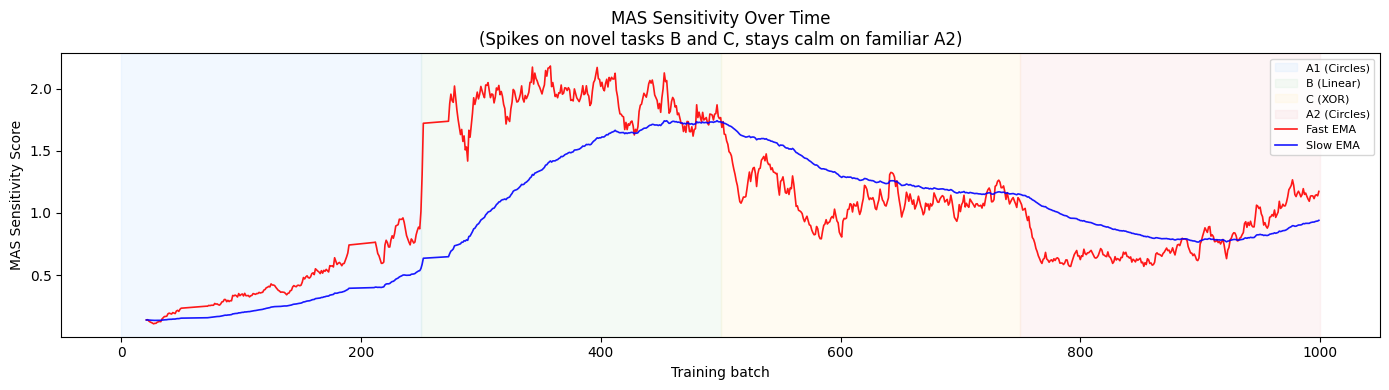

In [7]:
# Use the mas results from seed=42
m_result   = all_results['mas_signal'][0]
mas_log  = m_result['mas_log']

if not mas_log:
    print('No MAS log — signal never activated.')
else:
    steps   = [m[0] for m in mas_log]
    phases  = [m[1] for m in mas_log]
    scores  = [m[2] for m in mas_log]

    phase_names  = ['A1 (Circles)', 'B (Linear)', 'C (XOR)', 'A2 (Circles)']
    phase_colors = ['#cce5ff', '#d4edda', '#fff3cd', '#f8d7da']

    fig, ax = plt.subplots(figsize=(14, 4))

    # Shade phases
    n_total = 4000 // 16 * 4
    phase_len = 4000 // 16
    for p, (name, color) in enumerate(zip(phase_names, phase_colors)):
        ax.axvspan(p * phase_len, (p+1) * phase_len, alpha=0.25, color=color, label=name)

    # Calculate EMAs for the plot
    fast_emas = []
    slow_emas = []
    f_ema = s_ema = scores[0]
    for s in scores:
        f_ema = 0.9 * f_ema + 0.1 * s
        s_ema = 0.99 * s_ema + 0.01 * s
        fast_emas.append(f_ema)
        slow_emas.append(s_ema)

    ax.plot(steps, fast_emas, color='red', linewidth=1.2, alpha=0.9, label='Fast EMA')
    ax.plot(steps, slow_emas, color='blue', linewidth=1.2, alpha=0.9, label='Slow EMA')

    ax.set_xlabel('Training batch')
    ax.set_ylabel('MAS Sensitivity Score')
    ax.set_title('MAS Sensitivity Over Time\n(Spikes on novel tasks B and C, stays calm on familiar A2)')
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

## Cell 8: Compare Results — Bar Chart

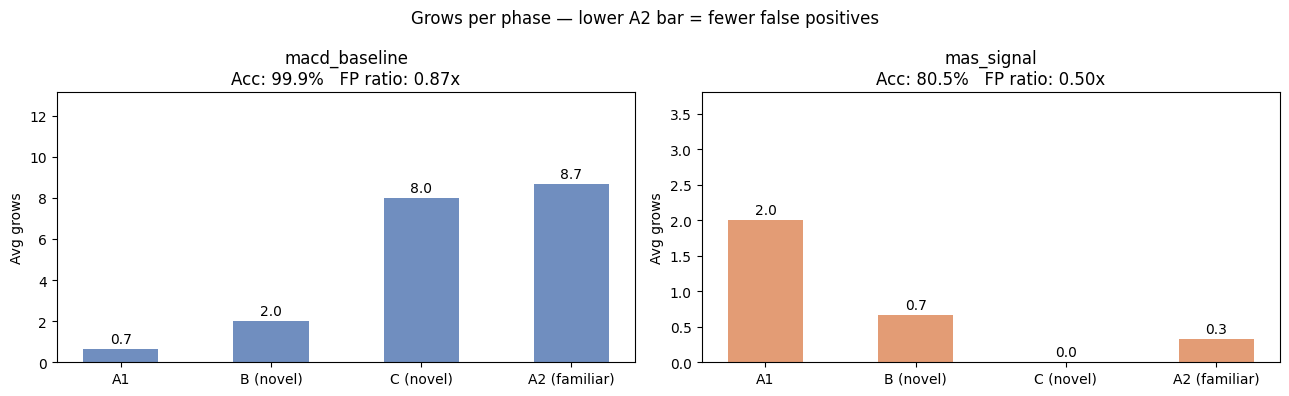

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels    = ['A1', 'B (novel)', 'C (novel)', 'A2 (familiar)']
x         = np.arange(len(labels))
bar_width  = 0.35
colors    = ['#4c72b0', '#dd8452']

for ax, mode, color in zip(axes, modes, colors):
    reps   = all_results[mode]
    means  = [
        np.mean([r['grows_A1']for r in reps]),
        np.mean([r['grows_B'] for r in reps]),
        np.mean([r['grows_C'] for r in reps]),
        np.mean([r['grows_A2']for r in reps]),
    ]
    bars = ax.bar(x, means, color=color, alpha=0.8, width=0.5)
    ax.bar_label(bars, fmt='%.1f', padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Avg grows')
    acc = np.mean([r['acc']for r in reps]) * 100
    fp  = means[3] / max(means[1]+means[2], 0.001)
    ax.set_title(f'{mode}\nAcc: {acc:.1f}%   FP ratio: {fp:.2f}x')
    ax.set_ylim(0, max(means) * 1.4 + 1)

fig.suptitle('Grows per phase — lower A2 bar = fewer false positives', fontsize=12)
plt.tight_layout()
plt.show()